# Homework 4: Optional Final Project (A+ Grade Bump)

- This homework template guides you through presenting your final project analysis. 
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/first-last/pipeline.py
```

## A. Describe Project

### **Guidance**
- State the policy question, puzzle, or social science problem you are addressing.
- Frame your central hypothesis and the expected relationship between your variables.
- Describe the scope of your analysis (e.g., geographical regions, years covered).
- Highlight the datasets you selected to examine this question.

### **Project Summary**
- **Project Title:** Tariffs, Trade Tension, and Inflation: Tariff-Exposed Commodity Prices as a Leading Indicator of CPI Pass-Through
- **Student Name:** Nafisa Mukhiddinova
- **Policy Relevance Statement:** If tariff-exposed commodity prices move ahead of realized CPI, they can give policymakers and the Fed an early read on inflationary pass-through from trade policy, before it shows up in lagging CPI releases.
- **Central Hypothesis:** Our group's full project hypothesizes that a daily media-derived US–China trade tension sentiment index (BTTI, built from GDELT) Granger-causes tariff-exposed commodity futures prices (steel, aluminum, soybeans) ahead of realized tariff policy changes, and that adding this signal improves CPI pass-through nowcasts. This individual notebook works with the team's merged monthly macro/commodity panel (`00_MERGED_MONTHLY.csv`), which does not yet include the BTTI sentiment series, so it tests a scoped-down version of the secondary hypothesis: whether lagged growth in tariff-exposed metal futures (steel) adds predictive power for core CPI growth beyond a baseline model of PPI, Treasury term spread, and inflation expectations.

---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Primary Data Source:** Team-built master monthly panel (`00_MERGED_MONTHLY.csv`), itself merged by the team's own data-collection pipeline (`notebooks/data-collection/`) from FRED (CPI/PPI/Treasury yields/inflation expectations), World Bank Commodity Markets (spot prices), and Yahoo Finance (commodity futures)
- **Variables Retrieved:** `date`, CPI series (`cpi_nsa`, `cpi_sa`, `food_cpi_sa`, `energy_cpi_sa`, `core_cpi_sa`), `ppi_sa`, `infexp`, Treasury yields (`treasury_3mo`...`treasury_30yr`, `spread_10y_2y`), commodity spot prices (gold, silver, crude oil, natural gas, copper, wheat, soybeans, aluminum), and commodity futures (steel, natural gas, corn, lean hog, wheat, aluminum, copper, soybean, gold, crude oil)
- **Local Storage Path:** `data/final_project/nafisa-mukhiddinova/tariff_inflation_monthly.csv`

In [1]:
# Import and run your data acquisition script
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../../../src/final_project/nafisa-mukhiddinova/basic').resolve()))
import data
df_raw = data.run()
df_raw.head()


Data acquired and saved to data/final_project/nafisa-mukhiddinova/tariff_inflation_monthly.csv


,date,cpi_nsa,cpi_sa,infexp,treasury_3mo,treasury_2yr,treasury_5yr,treasury_10yr,treasury_30yr,spread_10y_2y,...,steel_futures,natural_gas_futures,corn_futures,lean_hog_futures,wheat_futures,aluminum_futures,copper_futures,soybean_futures,gold_futures,crude_oil_futures
0,2015-01-01,233.707,234.747,2.5,0.03,0.55,1.37,1.88,2.46,1.33,...,586.650000,2.929350,388.100000,74.356251,543.587500,2220.800000,2.653225,1000.150000,1252.924994,47.325500
1,2015-02-01,234.722,235.342,2.8,0.02,0.62,1.47,1.98,2.57,1.36,...,530.631579,2.754947,383.684211,65.123684,517.486842,2174.710526,2.623632,992.657895,1224.910522,50.724736
2,2015-03-01,236.119,235.976,3.0,0.03,0.64,1.52,2.04,2.63,1.40,...,491.363636,2.746909,382.943182,62.706818,508.579545,2056.147727,2.707932,978.659091,1177.768183,47.854091
3,2015-04-01,236.599,236.222,2.6,0.02,0.54,1.35,1.94,2.59,1.40,...,458.285714,2.591333,373.964286,67.823809,501.761905,2005.797619,2.752762,971.392857,1199.828578,54.628096
4,2015-05-01,237.805,237.001,2.8,0.02,0.61,1.54,2.20,2.96,1.59,...,453.200000,2.855950,359.237500,81.568750,489.987500,1953.550000,2.893375,957.850000,1198.215009,59.372000


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
- **Feature Engineering:** Computed month-over-month percent growth for core CPI, PPI, steel futures, and aluminum futures, then lagged the predictor growth rates (PPI, steel, aluminum) and the control series (Treasury 10y-2y spread, inflation expectations) by one month so each predictor is known before the CPI print it forecasts.
- **Pre-cleaned Observations:** 131 monthly rows (Jan 2015 – Dec 2025), single time-indexed panel (no cross-sectional merge needed since all series are already monthly and date-aligned in the team's master panel).
- **Final Dataset Observations:** 129 clean rows and 41 columns, after dropping the first two months lost to the pct-change/lag transformations.
- **Clean Data Path:** `data/final_project/nafisa-mukhiddinova/processed_tariff_inflation.csv`

In [2]:
import manipulate
df_clean = manipulate.run()
df_clean.head()


Data processed and saved to data/final_project/nafisa-mukhiddinova/processed_tariff_inflation.csv with shape (129, 41)


,date,cpi_nsa,cpi_sa,infexp,treasury_3mo,treasury_2yr,treasury_5yr,treasury_10yr,treasury_30yr,spread_10y_2y,...,crude_oil_futures,core_cpi_growth,ppi_growth,steel_growth,aluminum_growth,ppi_growth_lag1,steel_growth_lag1,aluminum_growth_lag1,spread_lag1,infexp_lag1
2,2015-03-01,236.119,235.976,3.0,0.03,0.64,1.52,2.04,2.63,1.40,...,47.854091,0.242743,0.209314,-7.400227,-5.451889,-0.468750,-9.548866,-2.075355,1.36,2.8
3,2015-04-01,236.599,236.222,2.6,0.02,0.54,1.35,1.94,2.59,1.40,...,54.628096,0.245478,-0.313316,-6.731862,-2.448759,0.209314,-7.400227,-5.451889,1.40,3.0
4,2015-05-01,237.805,237.001,2.8,0.02,0.61,1.54,2.20,2.96,1.59,...,59.372000,0.141705,1.309586,-1.109726,-2.604830,-0.313316,-6.731862,-2.448759,1.40,2.6
5,2015-06-01,238.638,237.657,2.7,0.02,0.69,1.68,2.36,3.11,1.67,...,59.828637,0.155572,0.723888,2.543529,-6.373828,1.309586,-1.109726,-2.604830,1.59,2.8
6,2015-07-01,238.654,238.034,2.8,0.03,0.67,1.63,2.32,3.07,1.65,...,50.930000,0.206970,-0.462012,1.095462,-3.820322,0.723888,2.543529,-6.373828,1.67,2.7


## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations & Observations**
- **Figure 1 Key Takeaway:** Indexed to January 2015, core CPI rises smoothly and gradually over the sample, while steel and aluminum futures are far more volatile and spike sharply around 2021–2022 (steel futures peak near 330 vs. a base of 100) — consistent with tariff-exposed metals reacting to trade-policy shocks well before CPI's slow-moving pass-through.
- **Figure 2 Key Takeaway:** Lagged PPI growth is positively associated with core CPI growth, with a clear upward-sloping regression line, confirming producer-price pass-through is a first-order driver of core inflation in this sample — the relationship motivating why PPI is included as a control before testing whether tariff-exposed commodities add anything on top of it.

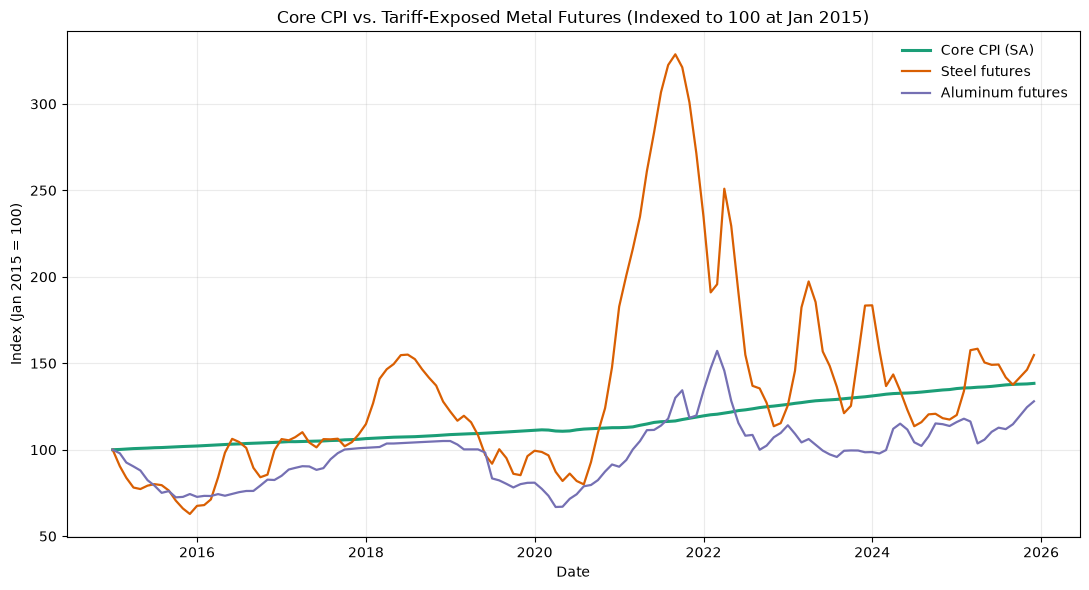

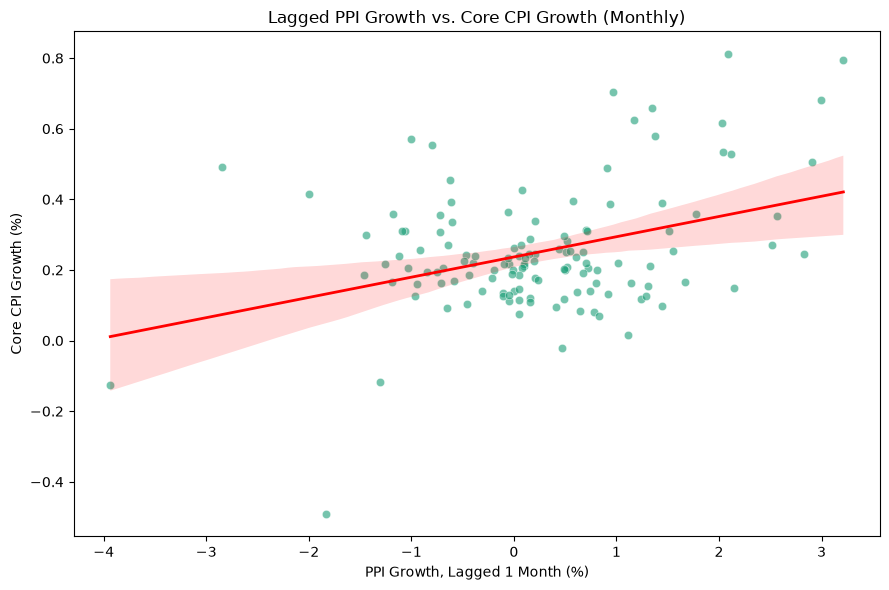

(<Figure size 1100x600 with 1 Axes>, <Figure size 900x600 with 1 Axes>)

In [3]:
import graph
graph.run()


## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
- **Model Type:** Ordinary Least Squares (OLS) time-series regression. Dependent variable: `core_cpi_growth` (month-over-month % change in core CPI). Independent variables: `ppi_growth_lag1`, `spread_lag1` (10y-2y Treasury spread), `infexp_lag1` (Michigan inflation expectations), `steel_growth_lag1` (tariff-exposed commodity proxy).
- **Model Fit Metrics:** R-squared = 0.332, Adj. R-squared = 0.311, Number of Observations = 129, F-statistic p-value = 2.87e-10.
- **Coefficient of Primary Variable (steel_growth_lag1):** Coefficient: 0.0001, Std. Err: 0.001, T-stat: 0.071 (p-value: 0.943) — not statistically significant.
- **Statistical Significance:** `ppi_growth_lag1` (coef 0.0459, p < 0.001) and `infexp_lag1` (coef 0.0765, p < 0.001) are highly significant; `spread_lag1` (p = 0.569) and `steel_growth_lag1` (p = 0.943) are not.
- **Key Conclusion:** Lagged PPI growth and inflation expectations are the dominant, statistically significant drivers of core CPI growth in this baseline monthly specification, consistent with standard pass-through channels. However, raw tariff-exposed steel futures growth shows **no** significant added predictive power once these controls are included — this does not support the primary hypothesis at the monthly, raw-price-growth level. This is not surprising given the project's own design: the group's hypothesis is specifically that a *sentiment-derived* signal (BTTI, built from GDELT news tone/volume around trade tension) is the leading indicator, not raw commodity price growth itself, and BTTI was not part of the merged file used here. The result is consistent with the team's broader finding that the predictive signal likely lives in the sentiment index and daily/short-lag futures reactions (Figure 1 shows steel/aluminum futures are far more volatile than CPI, spiking well ahead of and beyond CPI's smooth trend), rather than in monthly commodity price growth alone — motivating the full team pipeline's use of BTTI and daily-frequency Granger causality tests.

In [4]:
import model
summary = model.run()


=== Regression Results Summary ===
                            OLS Regression Results                            
Dep. Variable:        core_cpi_growth   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     15.43
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           2.87e-10
Time:                        18:21:45   Log-Likelihood:                 68.083
No. Observations:                 129   AIC:                            -126.2
Df Residuals:                     124   BIC:                            -111.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
con